In [1]:
import sys

from pybit.unified_trading import HTTP
import pandas as pd
from datetime import datetime, timezone
import ta
from pprint import pprint

import backtrader as bt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


from IPython.display import Image

%matplotlib inline

In [2]:
session = HTTP(
    testnet = False,
    api_key = "HLi00xLe7J1D5sfnH0",
    api_secret = "Rtw4VR7jjaOv5U8GfeTC1D2gGMf5ZqoQoP3U",
)

In [3]:
klines = session.get_kline(
    category="linear",
    symbol="BTCUSDT",
    interval=5,
    limit = 1000,
)

In [4]:
df_btcusdt = pd.DataFrame(data = klines['result']['list'], columns = ['unix_ts', 'open', 'high', 'low', 'close', 'volume_ticker', 'volume'] )
df_btcusdt.sort_values(by = 'unix_ts', inplace = True )
df_btcusdt.reset_index(drop = True, inplace = True )

df_btcusdt['ts'] = df_btcusdt['unix_ts'].apply(lambda x: datetime.fromtimestamp(int(x) / 1000) )
df_btcusdt.set_index('ts', inplace = True)
df_btcusdt.index.name = None
df_btcusdt = df_btcusdt[['open', 'high', 'low', 'close', 'volume']]
df_btcusdt[['open', 'high', 'low', 'close', 'volume']] = df_btcusdt[['open', 'high', 'low', 'close', 'volume']].astype('float') 

df_btcusdt

,open,high,low,close,volume
2026-09-24 09:30:00,84149.0,84180.0,84107.7,84146.6,8.409157e+06
2026-09-24 09:35:00,84146.6,84167.7,84119.4,84143.5,7.333536e+06
2026-09-24 09:40:00,84143.5,84164.2,84112.7,84144.3,5.297470e+06
2026-09-24 09:45:00,84144.3,84155.0,84026.2,84113.6,8.560464e+06
2026-09-24 09:50:00,84113.6,84126.0,84052.3,84071.0,3.428156e+06
...,...,...,...,...,...
2026-09-27 20:25:00,84422.4,84422.4,84392.3,84396.8,1.903412e+06
2026-09-27 20:30:00,84396.8,84466.2,84396.7,84466.2,5.941808e+06
2026-09-27 20:35:00,84466.2,84485.0,84430.4,84450.0,4.225962e+06
2026-09-27 20:40:00,84450.0,84450.0,84430.0,84446.9,1.429215e+06


In [5]:
class DonchianStrategy(bt.Strategy):

    params = (
        ('period', 24),
    )

    def __init__(self):

        self.donchian_high = bt.indicators.Highest(
            self.data.high(-1),
            period=self.p.period
        )

        self.donchian_low = bt.indicators.Lowest(
            self.data.low(-1),
            period=self.p.period
        )

        self.donchian_high.plotinfo.subplot = False
        self.donchian_low.plotinfo.subplot = False

        self.donchian_high.plotinfo.plotname = 'Donchian High'
        self.donchian_low.plotinfo.plotname = 'Donchian Low'

    def next(self):

        # Если уже в позиции — ничего не делаем
        if self.position:
            return

        # Пробой верхней границы → покупка
        if self.data.close[0] > self.donchian_high[0]:
            self.buy()

        # Пробой нижней границы → продажа
        elif self.data.close[0] < self.donchian_low[0]:
            self.sell()

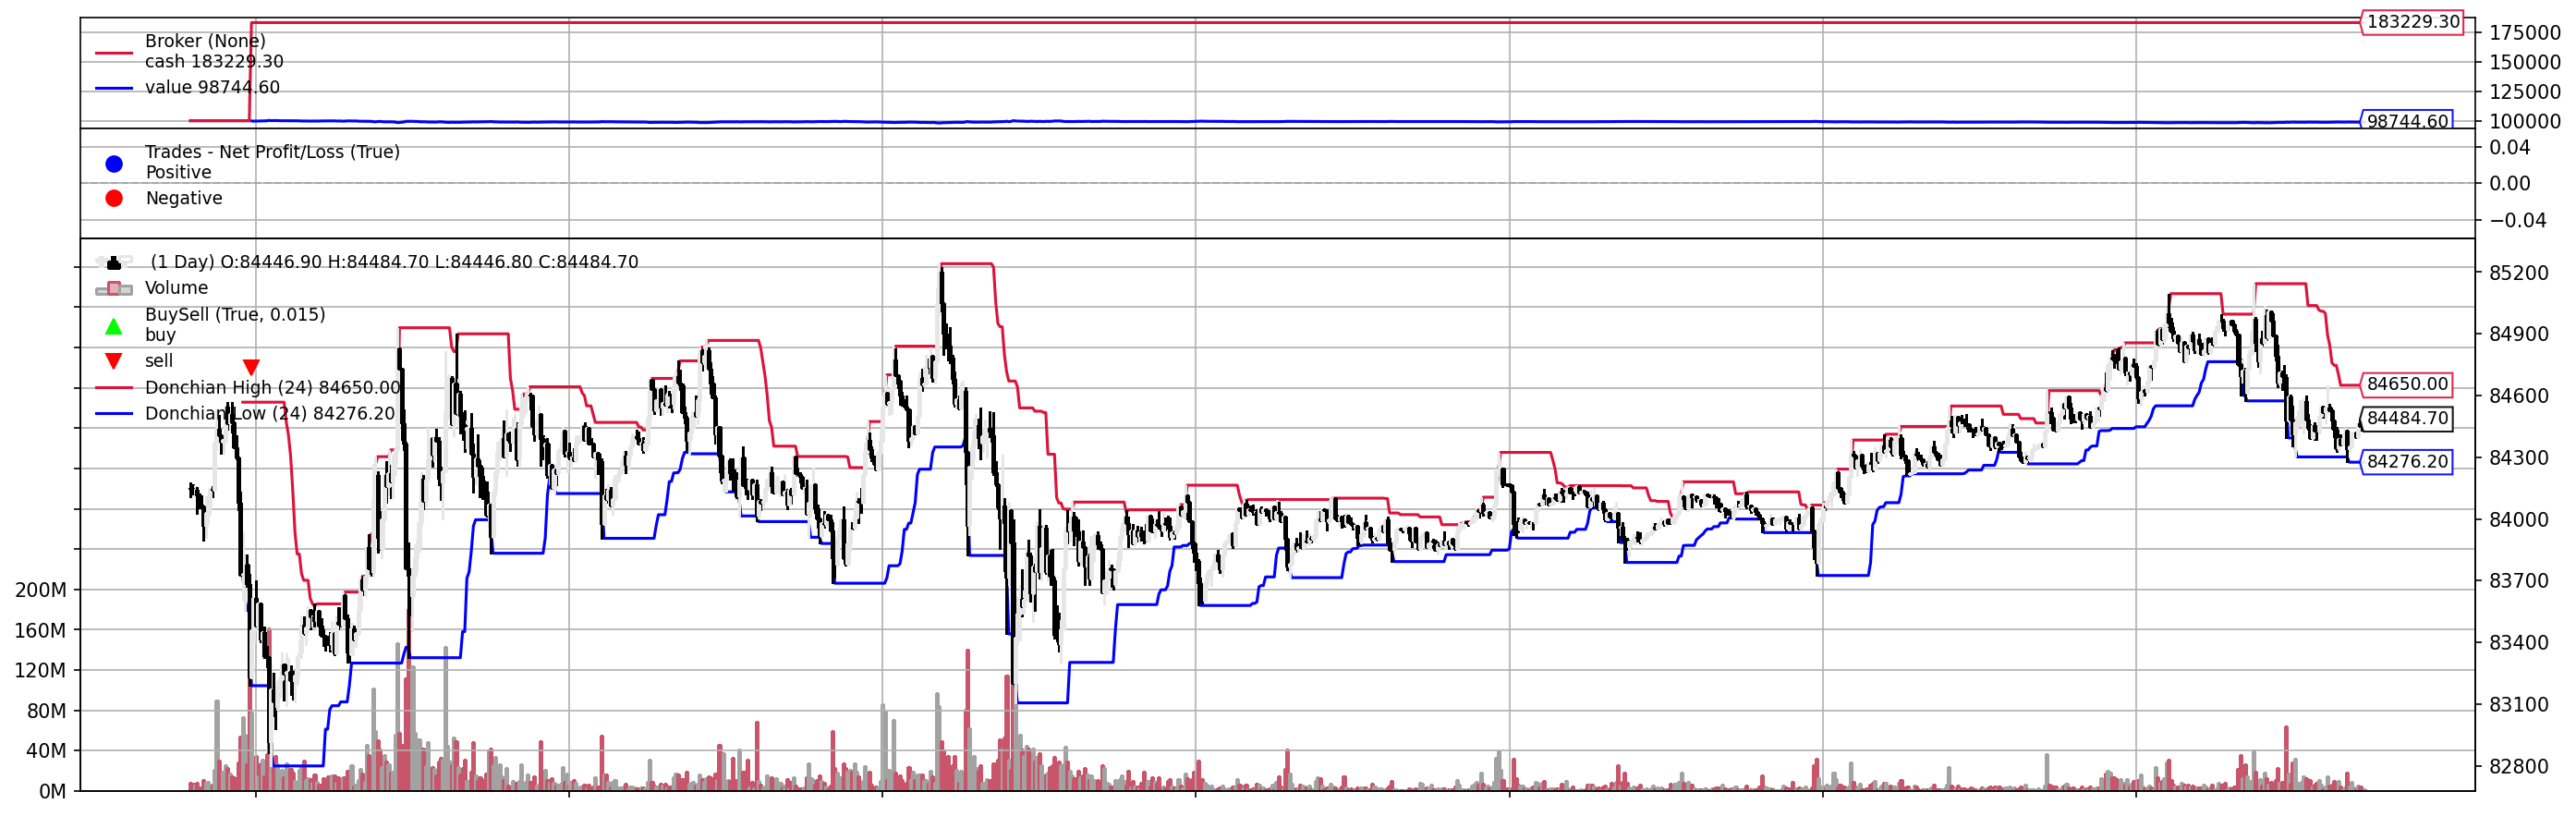

In [6]:
cerebro = bt.Cerebro()

data = bt.feeds.PandasData(
    dataname=df_btcusdt,
    datetime=None,
    open='open',
    high='high',
    low='low',
    close='close',
    volume='volume',
    openinterest=-1
)

cerebro.adddata(data)

cerebro.broker.setcash(100000)

# Добавляем стратегию
cerebro.addstrategy(
    DonchianStrategy,
    period=24
)

cerebro.run()

plt.rcParams["figure.figsize"] = (20, 6)

figs = cerebro.plot(
    style='candlestick',
    iplot=False,              # для этого способа неважно
    barup='white',
    bardown='black',
    # fmt_x_ticks='%d.%m %H:%M',   # если даты не нужны — можно убрать
)

img_path = "backtrader_plot.png"
figs[0][0].savefig(img_path, dpi=150, bbox_inches='tight')
Image(filename=img_path)


In [1]:
print(df_btcusdt.index)
print(df_btcusdt.index.dtype)

NameError: name 'df_btcusdt' is not defined

In [83]:
import backtrader
print(backtrader.__file__)

/Users/alexander.lezzov/wb_venv/lib/python3.12/site-packages/backtrader/__init__.py
